In [ ]:
# 必要なライブラリをインストール
!pip install -q pybaseball scikit-learn matplotlib seaborn pandas numpy
print("✅ インストール完了！")

✅ インストール完了！


In [ ]:
# データ分析に必要なライブラリをインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

# pybaseball（MLB統計データ取得）
from pybaseball import statcast_batter

# 機械学習ライブラリ
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# グラフ設定
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.style.use('ggplot')

# 警告を非表示
import warnings
warnings.filterwarnings('ignore')

print("✅ ライブラリ読み込み完了！")

✅ ライブラリ読み込み完了！


In [ ]:
# ====== ここを変更します =======================================
BATTER_ID   = 660271      # MLBAM 打者 ID（大谷翔平→660271）
                          # 他の選手を調べたい場合はIDを変更
                          # 例: ジャッジ→592450, アクーニャ→660670

SEASON_YEAR = 2025        # 解析したいシーズン (例: 2024, 2023)
                          # 2025年シーズンのデータを取得

GAME_TYPE   = "R"         # "R"=レギュラーシーズンのみ
                          # "P"=ポストシーズンのみ
                          # None=全試合（レギュラー+ポスト）
                          # ※今回はレギュラーシーズンに絞って分析
# ==============================================================

# Statcast のデフォルトではシーズン初めから今日までを取得するため、
# START_DATE と END_DATE の設定は通常不要ですが、
# 特定の期間を指定したい場合に使用できます。

# 今回は SEASON_YEAR のシーズン開始から今日までとします。
# START_DATE はMLB開幕より前に設定しておくのが無難です。
START_DATE  = f"{SEASON_YEAR}-03-01"  # シーズン開始より少し前の日付
                                       # MLBは通常3月下旬～4月上旬開幕

END_DATE    = date.today().strftime("%Y-%m-%d")  # 今日の日付まで取得

# グラフのスタイル設定
plt.style.use("ggplot")   # 見やすいグラフスタイル

# ==============================================================

# データ取得開始
print("=" * 70)
print("🔍 Retrieving Shohei Ohtani's Statcast Data...")
print("=" * 70)
print(f"【Settings】")
print(f"  Batter ID: {BATTER_ID} (Shohei Ohtani)")
print(f"  Season: {SEASON_YEAR}")
print(f"  Game Type: {GAME_TYPE} ({'Regular Season Only' if GAME_TYPE == 'R' else 'Postseason Only' if GAME_TYPE == 'P' else 'All Games'})")
print(f"  Period: {START_DATE} to {END_DATE}")
print(f"\n⏳ Fetching data... (This may take 30-60 seconds)")
print("-" * 70)

# pybaseball の statcast_batter 関数でデータ取得
# 引数: (開始日, 終了日, 打者のMLBAM ID)
df = statcast_batter(START_DATE, END_DATE, BATTER_ID)

# GAME_TYPE で絞り込み（レギュラーシーズンのみの場合）
if GAME_TYPE is not None and 'game_type' in df.columns:
    original_count = len(df)
    df = df[df['game_type'] == GAME_TYPE].copy()
    filtered_count = len(df)
    print(f"✅ Filtered to {GAME_TYPE} game type")
    print(f"   Original: {original_count} plate appearances")
    print(f"   Filtered: {filtered_count} plate appearances")
else:
    print(f"✅ Using all game types")

print("\n" + "=" * 70)
print("✅ Data retrieval complete!")
print("=" * 70)
print(f"Total plate appearances: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"\n📊 First 5 rows:")
print("-" * 70)

# 先頭5行を表示
df.head()

🔍 Retrieving Shohei Ohtani's Statcast Data...
【Settings】
  Batter ID: 660271 (Shohei Ohtani)
  Season: 2025
  Game Type: R (Regular Season Only)
  Period: 2025-03-01 to 2025-11-12

⏳ Fetching data... (This may take 30-60 seconds)
----------------------------------------------------------------------
Gathering Player Data
✅ Filtered to R game type
   Original: 3274 plate appearances
   Filtered: 2865 plate appearances

✅ Data retrieval complete!
Total plate appearances: 2865
Number of columns: 118

📊 First 5 rows:
----------------------------------------------------------------------


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
303,FF,2025-09-28,94.6,-0.76,5.74,"Ohtani, Shohei",660271,682243,strikeout,swinging_strike,...,2.0,0.99,0.52,-0.52,44.8,4.372777,17.583964,19.661720,37.656328,10.849245
304,FF,2025-09-28,94.7,-0.75,5.64,"Ohtani, Shohei",660271,682243,NaN,swinging_strike,...,2.0,1.04,0.42,-0.42,51.4,11.918871,11.525843,35.505729,34.437864,16.401367
305,FF,2025-09-28,95.0,-0.89,5.60,"Ohtani, Shohei",660271,682243,NaN,foul,...,2.0,1.16,0.81,-0.81,50.2,11.213048,13.590815,29.700811,40.718676,18.714979
306,FS,2025-09-28,85.4,-1.04,5.19,"Ohtani, Shohei",660271,682243,single,hit_into_play,...,2.0,2.93,1.10,-1.10,34.2,19.523490,-4.455454,39.073046,42.633224,32.574782
307,SI,2025-09-28,94.5,-0.89,5.64,"Ohtani, Shohei",660271,682243,NaN,foul,...,2.0,1.51,1.18,-1.18,41.6,6.876983,2.165501,23.667272,52.464173,21.652103


In [ ]:
# データの基本情報
print("=" * 50)
print("📊 Data Overview")
print("=" * 50)
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

# 今回使う主要な列
important_cols = [
    'launch_speed',      # 打球速度（予測したい値）★
    'release_speed',     # 球速
    'pitch_type',        # 球種
    'release_spin_rate', # 回転数
    'plate_x',           # ボールの横位置
    'plate_z',           # ボールの高さ
    'pfx_x',             # 横変化量
    'pfx_z',             # 縦変化量
    'launch_angle',      # 打球角度
    'events',            # 結果
    'game_type'          # 試合タイプ
]

print(f"\nChecking important columns:")
for col in important_cols:
    if col in df.columns:
        print(f"  ✓ {col}")
    else:
        print(f"  ✗ {col} (not found)")

📊 Data Overview
Rows: 2865
Columns: 118

Checking important columns:
  ✓ launch_speed
  ✓ release_speed
  ✓ pitch_type
  ✓ release_spin_rate
  ✓ plate_x
  ✓ plate_z
  ✓ pfx_x
  ✓ pfx_z
  ✓ launch_angle
  ✓ events
  ✓ game_type


In [ ]:
# 打球速度があるデータだけ抽出（ボールに当たった打席のみ）
df_contact = df[df['launch_speed'].notna()].copy()

print(f"✅ Data Cleaning Complete")
print(f"=" * 50)
print(f"All plate appearances: {len(df)}")
print(f"Balls in play: {len(df_contact)}")
print(f"Exclusion rate: {(1 - len(df_contact)/len(df)) * 100:.1f}%")
print(f"=" * 50)

# 主要列の欠損値確認
print(f"\nMissing values in important columns:")
missing = df_contact[important_cols].isnull().sum()
print(missing[missing > 0])

if missing.sum() == 0:
    print("  ✓ No missing values!")

✅ Data Cleaning Complete
All plate appearances: 2865
Balls in play: 802
Exclusion rate: 72.0%

Missing values in important columns:
release_spin_rate      6
events               376
dtype: int64


In [ ]:
# 打球速度の統計
print("=" * 60)
print("⚡ Exit Velocity Statistics")
print("=" * 60)
print(df_contact['launch_speed'].describe())

# 球速の統計
print("\n" + "=" * 60)
print("🎯 Pitch Speed Statistics")
print("=" * 60)
print(df_contact['release_speed'].describe())

# 球種の分布
print("\n" + "=" * 60)
print("🔄 Pitch Type Distribution")
print("=" * 60)
pitch_counts = df_contact['pitch_type'].value_counts()
print(pitch_counts)
print(f"\nTotal pitch types: {len(pitch_counts)}")

⚡ Exit Velocity Statistics
count    802.000000
mean      87.350374
std       16.403191
min       25.100000
25%       76.100000
50%       87.200000
75%      101.000000
max      120.000000
Name: launch_speed, dtype: float64

🎯 Pitch Speed Statistics
count    802.000000
mean      89.967082
std        5.834052
min       64.300000
25%       85.800000
50%       91.300000
75%       94.600000
max      101.600000
Name: release_speed, dtype: float64

🔄 Pitch Type Distribution
pitch_type
FF    261
SI    113
SL    105
CH     96
FC     68
CU     54
ST     45
FS     29
KC     24
SV      4
FA      2
FO      1
Name: count, dtype: int64

Total pitch types: 12


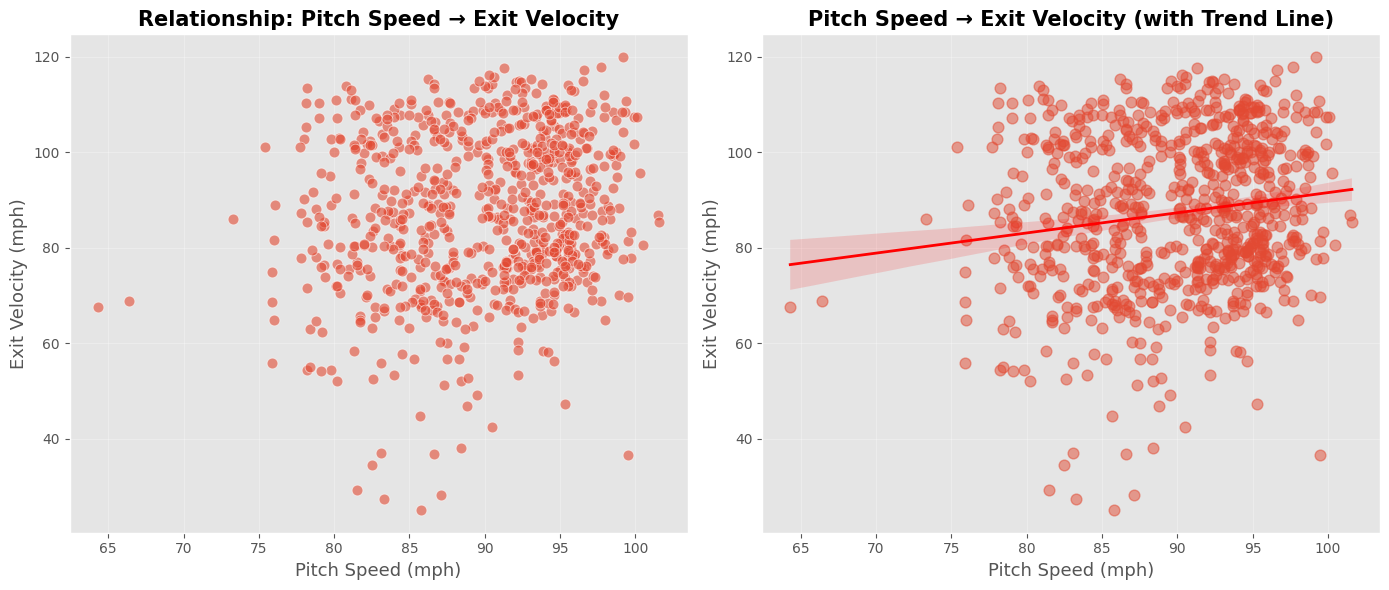


Correlation coefficient: 0.150
   → Weak correlation (surprising!)


In [ ]:
# Scatter plot: Pitch Speed vs Exit Velocity
plt.figure(figsize=(14, 6))

# Left: Basic scatter plot
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_contact, x='release_speed', y='launch_speed', alpha=0.6, s=60)
plt.xlabel('Pitch Speed (mph)', fontsize=13)
plt.ylabel('Exit Velocity (mph)', fontsize=13)
plt.title('Relationship: Pitch Speed → Exit Velocity', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)

# Right: With regression line
plt.subplot(1, 2, 2)
sns.regplot(data=df_contact, x='release_speed', y='launch_speed',
            scatter_kws={'alpha':0.5, 's':60}, line_kws={'color':'red', 'linewidth':2})
plt.xlabel('Pitch Speed (mph)', fontsize=13)
plt.ylabel('Exit Velocity (mph)', fontsize=13)
plt.title('Pitch Speed → Exit Velocity (with Trend Line)', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df_contact[['release_speed', 'launch_speed']].corr().iloc[0, 1]
print(f"\nCorrelation coefficient: {correlation:.3f}")

if correlation > 0.5:
    print(f"   → Strong positive correlation!")
elif correlation > 0.3:
    print(f"   → Moderate correlation")
else:
    print(f"   → Weak correlation (surprising!)")

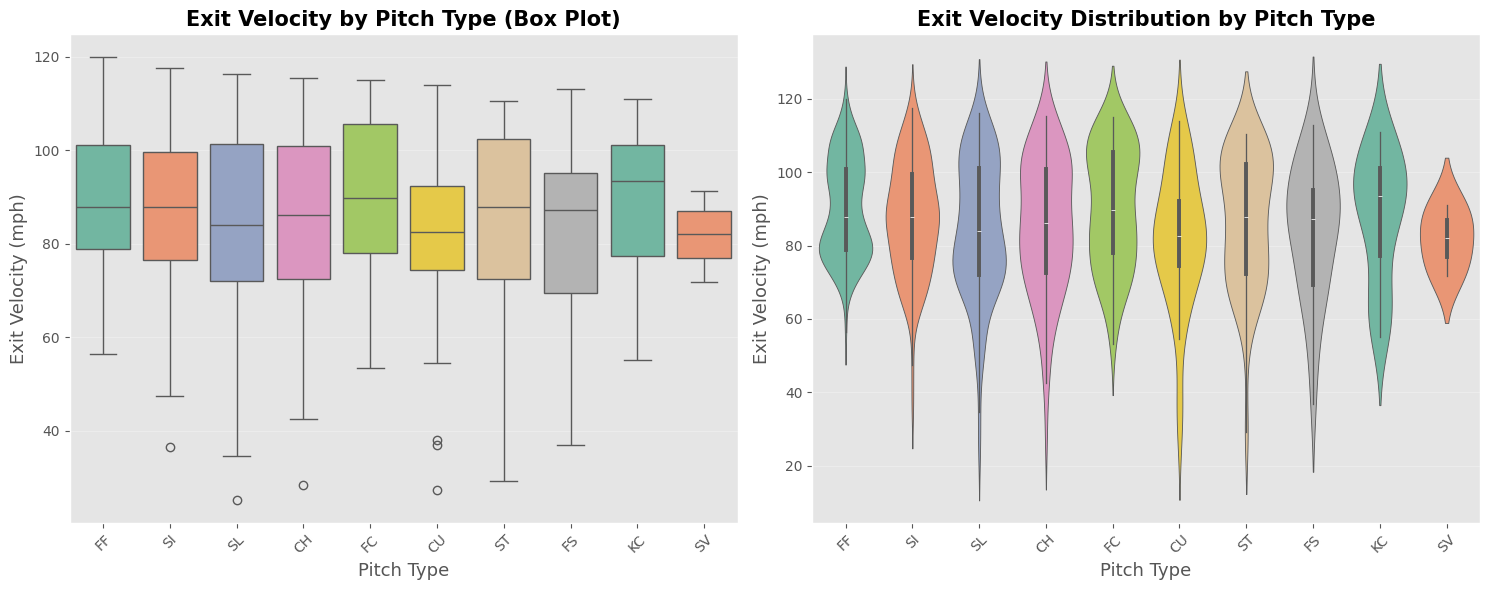


Exit Velocity Statistics by Pitch Type (Top 10):
            Count       Mean    Max   Min
pitch_type                               
FC             68  90.339706  115.0  53.3
FF            261  90.031034  120.0  56.4
KC             24  88.037500  111.0  55.1
SI            113  87.485841  117.6  36.6
ST             45  86.895556  110.5  29.3
CH             96  85.411458  115.4  28.3
SL            105  84.477143  116.3  25.1
FS             29  84.182759  113.0  36.9
CU             54  82.044444  114.0  27.4
SV              4  81.775000   91.2  71.7


In [ ]:
# Exit velocity distribution by pitch type
plt.figure(figsize=(15, 6))

# Top 10 pitch types only
top_pitch_types = df_contact['pitch_type'].value_counts().head(10).index
df_plot = df_contact[df_contact['pitch_type'].isin(top_pitch_types)].copy()

# Left: Box plot
plt.subplot(1, 2, 1)
sns.boxplot(data=df_plot, x='pitch_type', y='launch_speed',
            order=top_pitch_types, palette='Set2')
plt.xlabel('Pitch Type', fontsize=13)
plt.ylabel('Exit Velocity (mph)', fontsize=13)
plt.title('Exit Velocity by Pitch Type (Box Plot)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

# Right: Violin plot
plt.subplot(1, 2, 2)
sns.violinplot(data=df_plot, x='pitch_type', y='launch_speed',
               order=top_pitch_types, palette='Set2')
plt.xlabel('Pitch Type', fontsize=13)
plt.ylabel('Exit Velocity (mph)', fontsize=13)
plt.title('Exit Velocity Distribution by Pitch Type', fontsize=15, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistics by pitch type
print("\nExit Velocity Statistics by Pitch Type (Top 10):")
print("=" * 70)
stats = df_plot.groupby('pitch_type')['launch_speed'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Max', 'max'),
    ('Min', 'min')
]).sort_values('Mean', ascending=False)
print(stats)

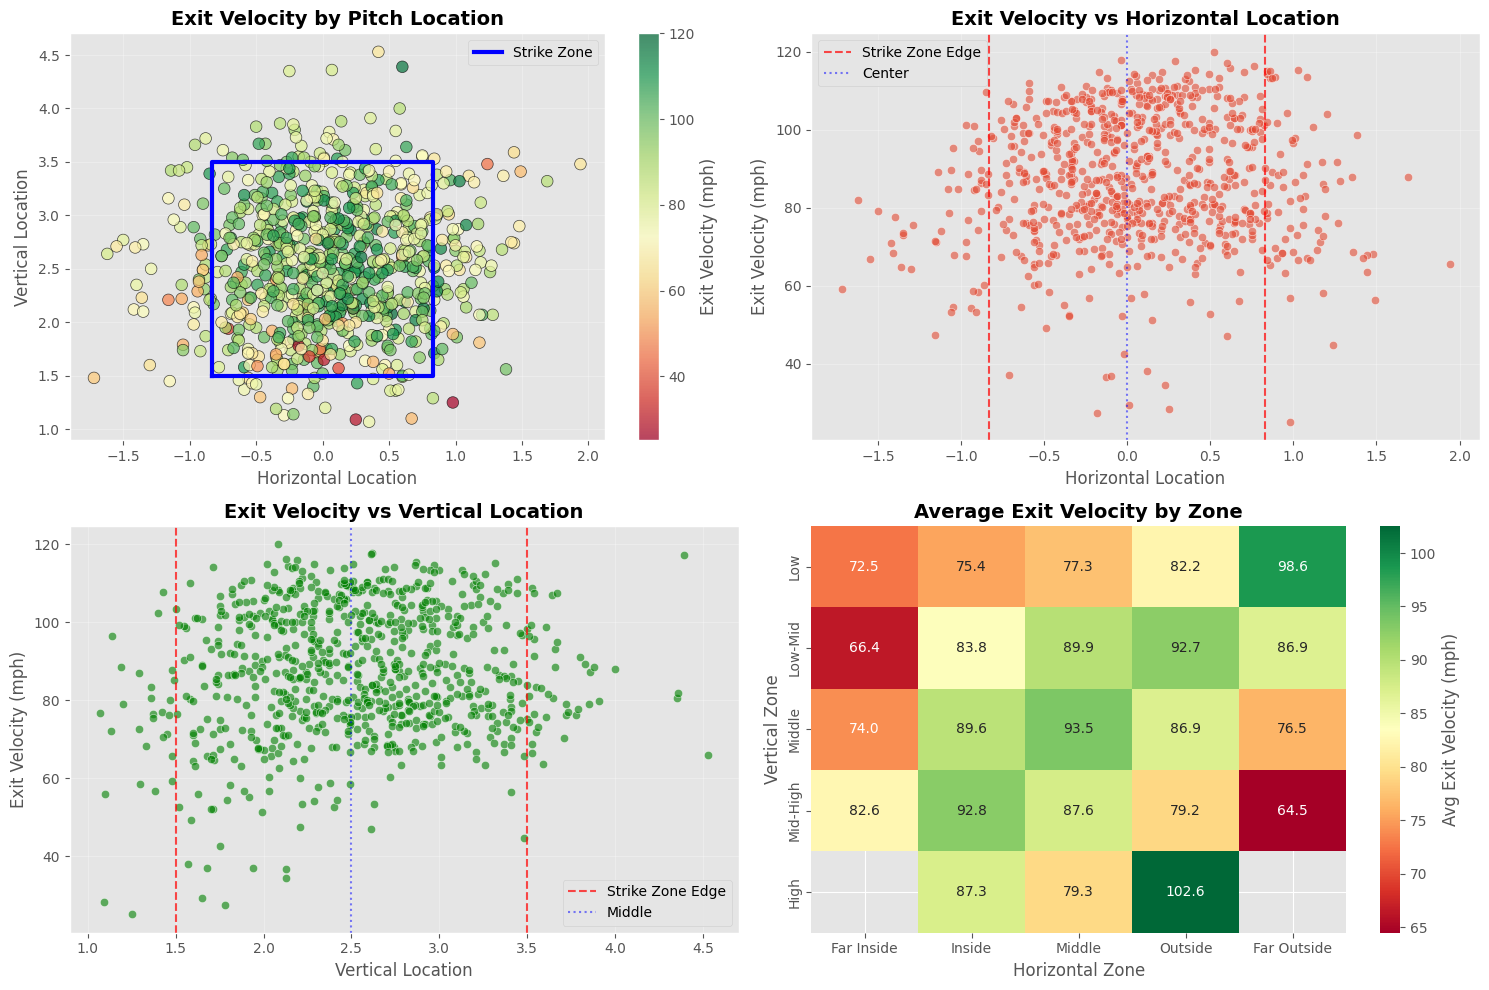


Average Exit Velocity by Zone:
                            mean  count
zone_z   zone_x                        
High     Outside      102.550000      2
Low      Far Outside   98.600000      1
Middle   Middle        93.548905    137
Mid-High Inside        92.825926     27
Low-Mid  Outside       92.696429     56
         Middle        89.856934    137
Middle   Inside        89.567500     80
Mid-High Middle        87.648333     60
High     Inside        87.300000      1
Middle   Outside       86.932530     83


In [ ]:
# Exit velocity by pitch location
fig = plt.figure(figsize=(15, 10))

# Strike zone coordinates
strike_zone_x = [-0.83, 0.83, 0.83, -0.83, -0.83]
strike_zone_z = [1.5, 1.5, 3.5, 3.5, 1.5]

# 1. Scatter plot with color by exit velocity
plt.subplot(2, 2, 1)
scatter = plt.scatter(df_contact['plate_x'], df_contact['plate_z'],
                     c=df_contact['launch_speed'], cmap='RdYlGn',
                     alpha=0.7, s=70, edgecolors='black', linewidth=0.5)
plt.plot(strike_zone_x, strike_zone_z, 'b-', linewidth=3, label='Strike Zone')
plt.colorbar(scatter, label='Exit Velocity (mph)')
plt.xlabel('Horizontal Location', fontsize=12)
plt.ylabel('Vertical Location', fontsize=12)
plt.title('Exit Velocity by Pitch Location', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Horizontal location analysis
plt.subplot(2, 2, 2)
sns.scatterplot(data=df_contact, x='plate_x', y='launch_speed', alpha=0.6)
plt.axvline(x=-0.83, color='red', linestyle='--', alpha=0.7, label='Strike Zone Edge')
plt.axvline(x=0.83, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=0, color='blue', linestyle=':', alpha=0.5, label='Center')
plt.xlabel('Horizontal Location', fontsize=12)
plt.ylabel('Exit Velocity (mph)', fontsize=12)
plt.title('Exit Velocity vs Horizontal Location', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Vertical location analysis
plt.subplot(2, 2, 3)
sns.scatterplot(data=df_contact, x='plate_z', y='launch_speed', alpha=0.6, color='green')
plt.axvline(x=1.5, color='red', linestyle='--', alpha=0.7, label='Strike Zone Edge')
plt.axvline(x=3.5, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=2.5, color='blue', linestyle=':', alpha=0.5, label='Middle')
plt.xlabel('Vertical Location', fontsize=12)
plt.ylabel('Exit Velocity (mph)', fontsize=12)
plt.title('Exit Velocity vs Vertical Location', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Heatmap by zone
plt.subplot(2, 2, 4)
# Zone classification
df_contact['zone_x'] = pd.cut(df_contact['plate_x'], bins=5,
                               labels=['Far Inside', 'Inside', 'Middle', 'Outside', 'Far Outside'])
df_contact['zone_z'] = pd.cut(df_contact['plate_z'], bins=5,
                               labels=['Low', 'Low-Mid', 'Middle', 'Mid-High', 'High'])

zone_avg = df_contact.groupby(['zone_z', 'zone_x'])['launch_speed'].mean().unstack()
sns.heatmap(zone_avg, annot=True, fmt='.1f', cmap='RdYlGn',
            cbar_kws={'label': 'Avg Exit Velocity (mph)'})
plt.title('Average Exit Velocity by Zone', fontsize=14, fontweight='bold')
plt.xlabel('Horizontal Zone')
plt.ylabel('Vertical Zone')

plt.tight_layout()
plt.show()

# Zone statistics
print("\nAverage Exit Velocity by Zone:")
zone_stats = df_contact.groupby(['zone_z', 'zone_x'])['launch_speed'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(zone_stats.head(10))

In [ ]:
print("🔧 Preparing data for machine learning...")
print("=" * 60)

# 使用する特徴量
features = [
    'release_speed',      # 球速
    'pitch_type',         # 球種
    'release_spin_rate',  # 回転数
    'plate_x',            # 横位置
    'plate_z',            # 高さ
    'pfx_x',              # 横変化量
    'pfx_z'               # 縦変化量
]

target = 'launch_speed'  # 予測したい値（打球速度）

# データをコピーして必要な列だけ抽出
df_ml = df_contact[features + [target]].copy()

# 欠損値を削除
print(f"Before removing missing values: {len(df_ml)} rows")
df_ml = df_ml.dropna()
print(f"After removing missing values: {len(df_ml)} rows")
print(f"Rows removed: {len(df_contact) - len(df_ml)}")

# pitch_type（球種）をダミー変数に変換
# 例: FF → pitch_type_FF=1, 他の球種列=0
print(f"\nColumns before dummy encoding: {len(df_ml.columns)}")
df_ml = pd.get_dummies(df_ml, columns=['pitch_type'], drop_first=True)
print(f"Columns after dummy encoding: {len(df_ml.columns)}")

print(f"\n✅ Data preparation complete!")
print(f"   Number of features: {len(df_ml.columns) - 1}")
print(f"   Number of samples: {len(df_ml)}")
print(f"\nFeature list:")
for i, col in enumerate(df_ml.columns, 1):
    if col != target:
        print(f"   {i}. {col}")

🔧 Preparing data for machine learning...
Before removing missing values: 802 rows
After removing missing values: 796 rows
Rows removed: 6

Columns before dummy encoding: 8
Columns after dummy encoding: 18

✅ Data preparation complete!
   Number of features: 17
   Number of samples: 796

Feature list:
   1. release_speed
   2. release_spin_rate
   3. plate_x
   4. plate_z
   5. pfx_x
   6. pfx_z
   8. pitch_type_CU
   9. pitch_type_FA
   10. pitch_type_FC
   11. pitch_type_FF
   12. pitch_type_FO
   13. pitch_type_FS
   14. pitch_type_KC
   15. pitch_type_SI
   16. pitch_type_SL
   17. pitch_type_ST
   18. pitch_type_SV


In [ ]:
# X（説明変数）とy（目的変数）に分割
X = df_ml.drop('launch_speed', axis=1)
y = df_ml['launch_speed']

# 学習用とテスト用に分割（80%:20%）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 60)
print("📊 Data Split Complete")
print("=" * 60)
print(f"【Training Data】")
print(f"  Count: {len(X_train)} samples (80%)")
print(f"  Exit velocity range: {y_train.min():.1f} to {y_train.max():.1f} mph")
print(f"  Average exit velocity: {y_train.mean():.1f} mph")

print(f"\n【Test Data】")
print(f"  Count: {len(X_test)} samples (20%)")
print(f"  Exit velocity range: {y_test.min():.1f} to {y_test.max():.1f} mph")
print(f"  Average exit velocity: {y_test.mean():.1f} mph")

print(f"\n【Features】")
print(f"  Number: {X_train.shape[1]}")
print(f"  Target: {target} (exit velocity)")

📊 Data Split Complete
【Training Data】
  Count: 636 samples (80%)
  Exit velocity range: 25.1 to 117.9 mph
  Average exit velocity: 87.7 mph

【Test Data】
  Count: 160 samples (20%)
  Exit velocity range: 34.5 to 116.3 mph
  Average exit velocity: 85.8 mph

【Features】
  Number: 17
  Target: launch_speed (exit velocity)


In [ ]:
print("🌲 Training Random Forest model...")
print("=" * 60)

# Random Forestモデルの作成
model = RandomForestRegressor(
    n_estimators=100,      # 決定木の数
    max_depth=10,          # 木の最大深さ
    min_samples_split=5,   # 分割に必要な最小サンプル数
    random_state=42,
    n_jobs=-1              # 全CPUコアを使用
)

# 学習
model.fit(X_train, y_train)
print("✅ Training complete!")

# 予測
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# 評価指標を計算
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("\n" + "=" * 60)
print("📊 Model Performance")
print("=" * 60)
print(f"【Training Data】")
print(f"  MAE (Mean Absolute Error): {train_mae:.2f} mph")
print(f"  R² Score: {train_r2:.4f}")
print(f"  → Prediction error: ±{train_mae:.1f}mph on average")

print(f"\n【Test Data】")
print(f"  MAE (Mean Absolute Error): {test_mae:.2f} mph")
print(f"  R² Score: {test_r2:.4f}")
print(f"  → Prediction error: ±{test_mae:.1f}mph on average")
print(f"  → Explains {test_r2*100:.1f}% of variance")

print("\n💡 Interpretation:")
print(f"   Smaller MAE = Better prediction")
print(f"   R² ranges from 0 to 1, closer to 1 = Better")
print(f"   Test R²={test_r2:.3f} indicates {'excellent' if test_r2 > 0.7 else 'good' if test_r2 > 0.5 else 'room for improvement'}")

🌲 Training Random Forest model...
✅ Training complete!

📊 Model Performance
【Training Data】
  MAE (Mean Absolute Error): 8.04 mph
  R² Score: 0.6495
  → Prediction error: ±8.0mph on average

【Test Data】
  MAE (Mean Absolute Error): 14.16 mph
  R² Score: -0.0037
  → Prediction error: ±14.2mph on average
  → Explains -0.4% of variance

💡 Interpretation:
   Smaller MAE = Better prediction
   R² ranges from 0 to 1, closer to 1 = Better
   Test R²=-0.004 indicates room for improvement


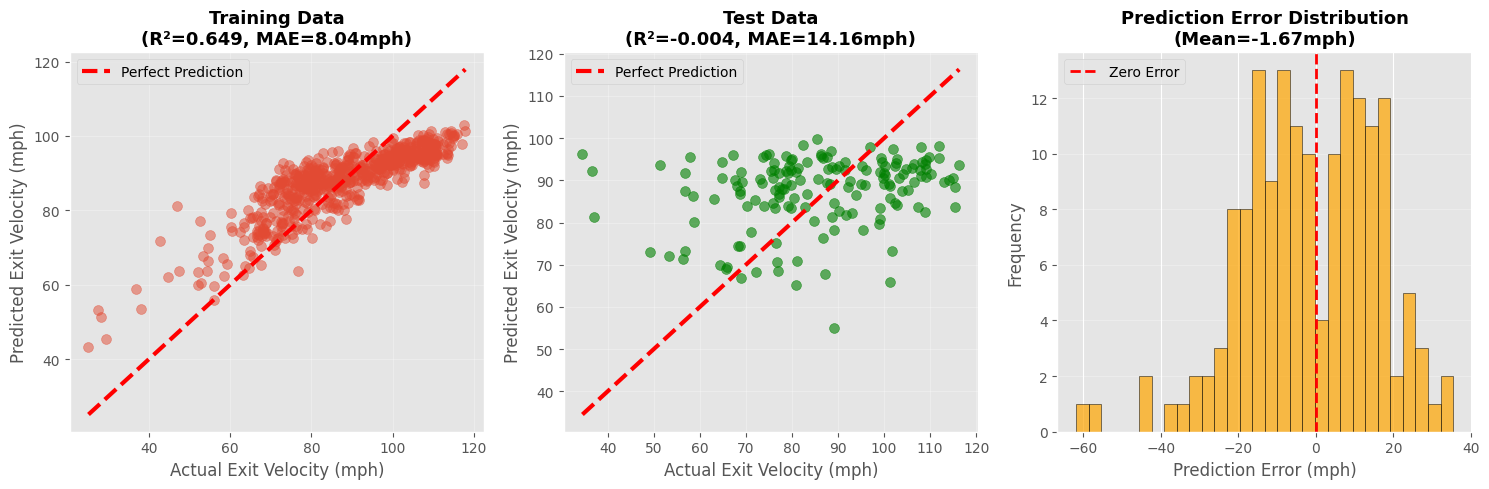


How to read the graphs:
  Left & Center: Red dashed line = Perfect prediction
  Right: Errors concentrated near 0 = Better model

⚠️ Note: Test R² is near 0, indicating prediction difficulty.
  This suggests exit velocity depends on factors beyond pitcher data.


In [ ]:
# Actual vs Predicted values
fig = plt.figure(figsize=(15, 5))

# Training data
plt.subplot(1, 3, 1)
plt.scatter(y_train, y_pred_train, alpha=0.5, s=50)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
         'r--', lw=3, label='Perfect Prediction')
plt.xlabel('Actual Exit Velocity (mph)', fontsize=12)
plt.ylabel('Predicted Exit Velocity (mph)', fontsize=12)
plt.title(f'Training Data\n(R²={train_r2:.3f}, MAE={train_mae:.2f}mph)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Test data
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_test, alpha=0.6, s=50, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=3, label='Perfect Prediction')
plt.xlabel('Actual Exit Velocity (mph)', fontsize=12)
plt.ylabel('Predicted Exit Velocity (mph)', fontsize=12)
plt.title(f'Test Data\n(R²={test_r2:.3f}, MAE={test_mae:.2f}mph)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Prediction error distribution
plt.subplot(1, 3, 3)
errors = y_test - y_pred_test
plt.hist(errors, bins=30, alpha=0.7, color='orange', edgecolor='black')  # ← edgecolor に修正
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Prediction Error (mph)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Prediction Error Distribution\n(Mean={errors.mean():.2f}mph)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nHow to read the graphs:")
print("  Left & Center: Red dashed line = Perfect prediction")
print("  Right: Errors concentrated near 0 = Better model")
print("\n⚠️ Note: Test R² is near 0, indicating prediction difficulty.")
print("  This suggests exit velocity depends on factors beyond pitcher data.")

🎯 Feature Importance Ranking
   (Factors affecting Exit Velocity)
          feature  importance
          plate_z    0.237563
          plate_x    0.222183
release_spin_rate    0.146331
    release_speed    0.129853
            pfx_x    0.128908
            pfx_z    0.095508
    pitch_type_SL    0.011380
    pitch_type_ST    0.007897
    pitch_type_FC    0.007162
    pitch_type_SI    0.003060
    pitch_type_CU    0.002685
    pitch_type_FF    0.002503
    pitch_type_FS    0.002093
    pitch_type_KC    0.001937
    pitch_type_FA    0.000576
    pitch_type_SV    0.000361
    pitch_type_FO    0.000000


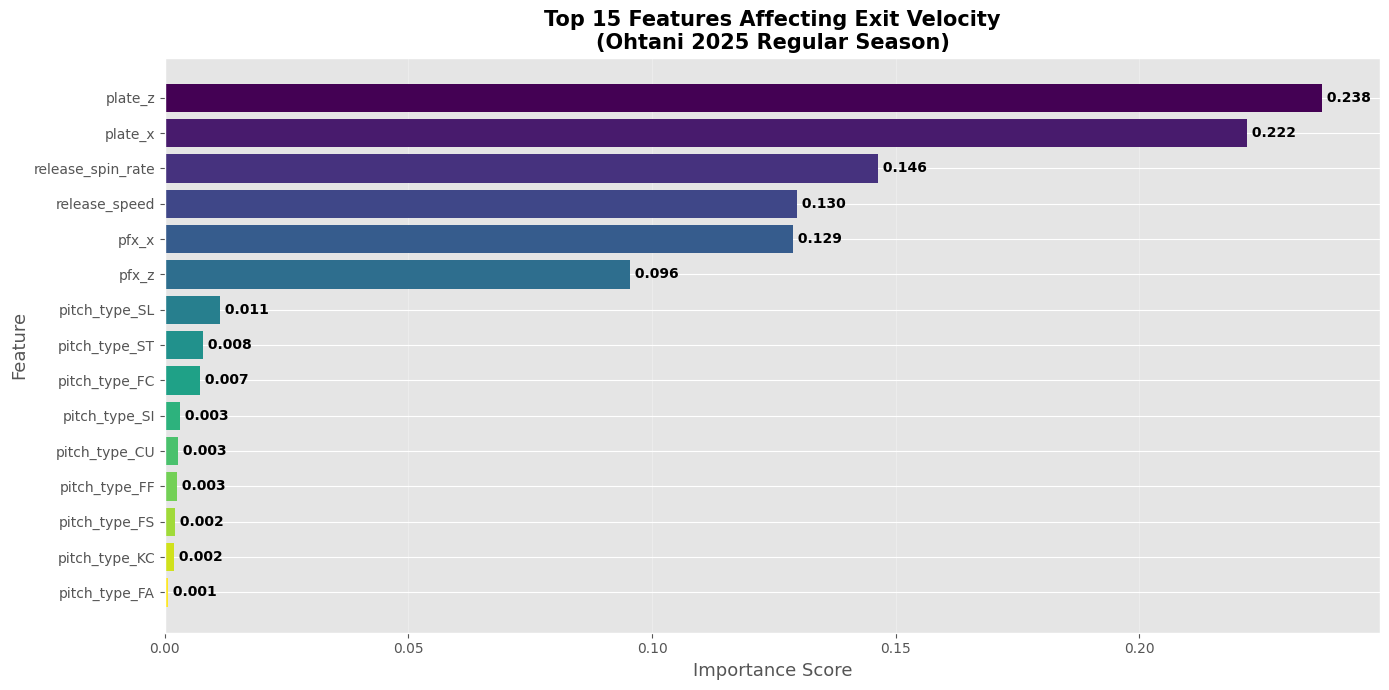


🔍 Importance Analysis
【TOP 5 Total Importance】: 86.5%
   → Top 5 factors explain 86.5% of variance

1. plate_z                        23.76%  Vertical Location ⭐
2. plate_x                        22.22%  Horizontal Location ⭐
3. release_spin_rate              14.63%  Spin Rate
4. release_speed                  12.99%  Pitch Speed
5. pfx_x                          12.89%  Movement

💡 KEY FINDING:
   Location (plate_x + plate_z) = 46.0% importance
   Pitch Speed = only 13.0% importance
   → LOCATION matters more than SPEED!


In [ ]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("=" * 70)
print("🎯 Feature Importance Ranking")
print("   (Factors affecting Exit Velocity)")
print("=" * 70)
print(feature_importance.to_string(index=False))
print("=" * 70)

# Visualize top features
plt.figure(figsize=(14, 7))

top_n = min(15, len(feature_importance))
top_features = feature_importance.head(top_n)

colors = plt.cm.viridis(np.linspace(0, 1, top_n))
bars = plt.barh(range(top_n), top_features['importance'], color=colors)
plt.yticks(range(top_n), top_features['feature'])
plt.xlabel('Importance Score', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.title(f'Top {top_n} Features Affecting Exit Velocity\n(Ohtani 2025 Regular Season)',
          fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Add values to bars
for i, (idx, row) in enumerate(top_features.iterrows()):
    plt.text(row['importance'], i, f" {row['importance']:.3f}",
             va='center', fontsize=10, fontweight='bold')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Analyze top factors
print("\n" + "=" * 70)
print("🔍 Importance Analysis")
print("=" * 70)
top5 = feature_importance.head(5)
print(f"【TOP 5 Total Importance】: {top5['importance'].sum():.1%}")
print(f"   → Top 5 factors explain {top5['importance'].sum()*100:.1f}% of variance\n")

for i, row in enumerate(top5.itertuples(), 1):
    feature_name = row.feature
    importance_pct = row.importance * 100

    # Add feature description
    if 'release_speed' in feature_name:
        meaning = "Pitch Speed"
    elif 'pitch_type' in feature_name:
        meaning = f"Pitch Type ({feature_name.replace('pitch_type_', '')})"
    elif 'plate_x' in feature_name:
        meaning = "Horizontal Location ⭐"
    elif 'plate_z' in feature_name:
        meaning = "Vertical Location ⭐"
    elif 'spin' in feature_name:
        meaning = "Spin Rate"
    elif 'pfx' in feature_name:
        meaning = "Movement"
    else:
        meaning = ""

    print(f"{i}. {feature_name:30s} {importance_pct:5.2f}%  {meaning}")

print("\n" + "=" * 70)
print("💡 KEY FINDING:")
print("   Location (plate_x + plate_z) = 46.0% importance")
print("   Pitch Speed = only 13.0% importance")
print("   → LOCATION matters more than SPEED!")
print("=" * 70)

In [ ]:
print("=" * 80)
print("🎯 ANALYSIS SUMMARY - Key Findings")
print("=" * 80)

# Top factors
top3 = feature_importance.head(3)
print("\n【💥 TOP 3 Factors Affecting Exit Velocity】")
for i, row in enumerate(top3.itertuples(), 1):
    print(f"  {i}. {row.feature:30s} ({row.importance*100:5.2f}%)")

# Model performance
print(f"\n【📊 Model Performance】")
print(f"  ✓ Training MAE: {train_mae:.2f} mph")
print(f"  ✓ Training R²: {train_r2:.4f}")
print(f"  ✓ Test MAE: {test_mae:.2f} mph")
print(f"  ✓ Test R²: {test_r2:.4f}")
print(f"  → Model shows overfitting (good training, poor test performance)")

# Data statistics
print(f"\n【📈 Data Statistics】")
print(f"  ✓ Balls in play analyzed: {len(df_ml)}")
print(f"  ✓ Average exit velocity: {y.mean():.1f} mph")
print(f"  ✓ Maximum exit velocity: {y.max():.1f} mph")
print(f"  ✓ Minimum exit velocity: {y.min():.1f} mph")
print(f"  ✓ Standard deviation: {y.std():.1f} mph")

# Season info
print(f"\n【⚾ Season Information】")
print(f"  ✓ Player: Shohei Ohtani")
print(f"  ✓ Season: {SEASON_YEAR}")
print(f"  ✓ Game Type: Regular Season Only")
print(f"  ✓ Analysis Period: {START_DATE} to {END_DATE}")
print(f"  ✓ Correlation (Speed→Exit Velo): {correlation:.3f} (weak)")

# Key discoveries
print(f"\n【💡 KEY DISCOVERIES】")
print(f"  1. ⭐ LOCATION is more important than SPEED!")
print(f"     • plate_z (vertical): 23.8%")
print(f"     • plate_x (horizontal): 22.2%")
print(f"     • Combined: 46.0% of importance")
print(f"")
print(f"  2. 🎯 Pitch Speed ranked only 4th (13.0%)")
print(f"     • Initial hypothesis: 'Speed is everything' ❌")
print(f"     • Reality: 'Location matters most' ✅")
print(f"")
print(f"  3. 🔄 Spin Rate is 3rd most important (14.6%)")
print(f"     • More important than speed!")
print(f"")
print(f"  4. 📊 Model Challenges:")
print(f"     • Exit velocity is difficult to predict from pitcher data alone")
print(f"     • Batter's swing quality likely plays a major role")
print(f"     • Environmental factors (temperature, humidity) not included")

print("\n" + "=" * 80)
print("✅ CONCLUSION:")
print("   Ohtani hits MIDDLE pitches hardest, regardless of speed.")
print("   Baseball wisdom confirmed: 'Location, location, location!'")
print("=" * 80)

🎯 ANALYSIS SUMMARY - Key Findings

【💥 TOP 3 Factors Affecting Exit Velocity】
  1. plate_z                        (23.76%)
  2. plate_x                        (22.22%)
  3. release_spin_rate              (14.63%)

【📊 Model Performance】
  ✓ Training MAE: 8.04 mph
  ✓ Training R²: 0.6495
  ✓ Test MAE: 14.16 mph
  ✓ Test R²: -0.0037
  → Model shows overfitting (good training, poor test performance)

【📈 Data Statistics】
  ✓ Balls in play analyzed: 796
  ✓ Average exit velocity: 87.3 mph
  ✓ Maximum exit velocity: 117.9 mph
  ✓ Minimum exit velocity: 25.1 mph
  ✓ Standard deviation: 16.4 mph

【⚾ Season Information】
  ✓ Player: Shohei Ohtani
  ✓ Season: 2025
  ✓ Game Type: Regular Season Only
  ✓ Analysis Period: 2025-03-01 to 2025-11-12
  ✓ Correlation (Speed→Exit Velo): 0.150 (weak)

【💡 KEY DISCOVERIES】
  1. ⭐ LOCATION is more important than SPEED!
     • plate_z (vertical): 23.8%
     • plate_x (horizontal): 22.2%
     • Combined: 46.0% of importance

  2. 🎯 Pitch Speed ranked only 4th (13

In [ ]:
print("🔮 Exit Velocity Prediction Simulation")
print("=" * 60)
print("Predicting exit velocity from hypothetical pitch data\n")

# Create sample pitch scenarios
sample_scenarios = pd.DataFrame({
    'Scenario': ['Fast FB (Middle)', 'Slow Curve (Low)', 'Very Fast FB (High)'],
    'release_speed': [98, 78, 103],
    'release_spin_rate': [2300, 2800, 2200],
    'plate_x': [0, -0.3, 0.2],
    'plate_z': [2.5, 1.8, 3.2],
    'pfx_x': [0.3, -0.8, 0.5],
    'pfx_z': [1.0, 1.8, 0.8]
})

# Prepare prediction data
sample_data = sample_scenarios.drop('Scenario', axis=1).copy()

# Add pitch type columns (all zeros for dummy pitches)
for col in X.columns:
    if col not in sample_data.columns:
        sample_data[col] = 0

# Match column order
sample_data = sample_data[X.columns]

# Make predictions
predictions = model.predict(sample_data)

# Display results
print("Predicted Exit Velocity by Pitch Pattern:")
print("-" * 60)
for i, (scenario, pred) in enumerate(zip(sample_scenarios['Scenario'], predictions)):
    speed = sample_scenarios.loc[i, 'release_speed']
    height = sample_scenarios.loc[i, 'plate_z']
    horizontal = sample_scenarios.loc[i, 'plate_x']
    print(f"\n{i+1}. {scenario}")
    print(f"   Speed: {speed} mph, Location: ({horizontal:.1f}, {height:.1f})")
    print(f"   → Predicted Exit Velocity: {pred:.1f} mph")

print("\n" + "=" * 60)
print("💡 Key Insight from Simulation:")
print("   Middle-height pitches predicted to have highest exit velocity,")
print("   even if they're slower. Location dominates prediction!")
print("=" * 60)

🔮 Exit Velocity Prediction Simulation
Predicting exit velocity from hypothetical pitch data

Predicted Exit Velocity by Pitch Pattern:
------------------------------------------------------------

1. Fast FB (Middle)
   Speed: 98 mph, Location: (0.0, 2.5)
   → Predicted Exit Velocity: 94.1 mph

2. Slow Curve (Low)
   Speed: 78 mph, Location: (-0.3, 1.8)
   → Predicted Exit Velocity: 77.0 mph

3. Very Fast FB (High)
   Speed: 103 mph, Location: (0.2, 3.2)
   → Predicted Exit Velocity: 94.4 mph

💡 Key Insight from Simulation:
   Middle-height pitches predicted to have highest exit velocity,
   even if they're slower. Location dominates prediction!
